In [115]:
import geopandas as gpd 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import functions.funcs as funcs 
import functions.plotting as plot
from importlib import reload
reload(plot)

<module 'functions.plotting' from 'c:\\FATE\\Code\\functions\\plotting.py'>

In [116]:
ds = gpd.read_parquet(r"Data\SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet")

In [117]:
longlist = pd.DataFrame(columns = ['BuoyID', 'TimeStamp', 'lat', 'lon'])

longlist['TimeStamp'], longlist['BuoyID'] = funcs.Column_to_List(ds, 'TimeStamp', True)
longlist['lat'], longlist['lon'] = funcs.list_of_latlon(ds, False)
longlist['TimeStamp'] = pd.to_datetime(longlist['TimeStamp'])

In [118]:
## amount of dFAD active on a given day 
daily = longlist.copy()
daily['day'] = daily['TimeStamp'].dt.date
daily_dFAD = daily.drop_duplicates(['BuoyID','day'])
daily = daily_dFAD.groupby('day', observed= False)['BuoyID'].count()
daily = daily.reset_index()
daily = daily.rename(columns={'BuoyID': 'dFADs'})
daily['year'] = pd.to_datetime(daily.day).dt.year
def print_stats(daily):
    print(daily.dFADs.mean(), daily.dFADs.min(), daily.dFADs.max(), daily.dFADs.std())
print_stats(daily)
daily.groupby('year', observed = False).apply(print_stats, include_groups = False)

25.471207430340556 1 103 15.139794906310634
5.0519480519480515 1 16 3.5309873969307453
21.172602739726027 3 46 9.17864908231958
32.326027397260276 2 103 19.12482153473624
25.352459016393443 5 58 12.236654210422026
31.649315068493152 9 64 11.428842481355925


""


In [119]:
target_day = pd.to_datetime("2024-4-25")
past = longlist[longlist.TimeStamp < pd.to_datetime(target_day)].copy()
past['day'] = past.TimeStamp.dt.date
past['last_date'] = past.groupby('BuoyID', observed = False)['day'].transform('last')
past['last_date'] = pd.to_datetime(past['last_date'])
activeday = past[past['last_date'] == (target_day - pd.Timedelta(1, 'day'))].copy()
activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()
gap = pd.Timedelta(days=2)

# Build segment IDs that increment at each large time gap
seg_id = activeday['deltat'].ge(gap).groupby(activeday['BuoyID']).cumsum()

# Keep only the most recent segment per buoy (or all rows if no gap >= 2 days)
activeday = activeday[seg_id == seg_id.groupby(activeday['BuoyID']).transform('max')].copy()
activeday = activeday.set_index(['BuoyID'])

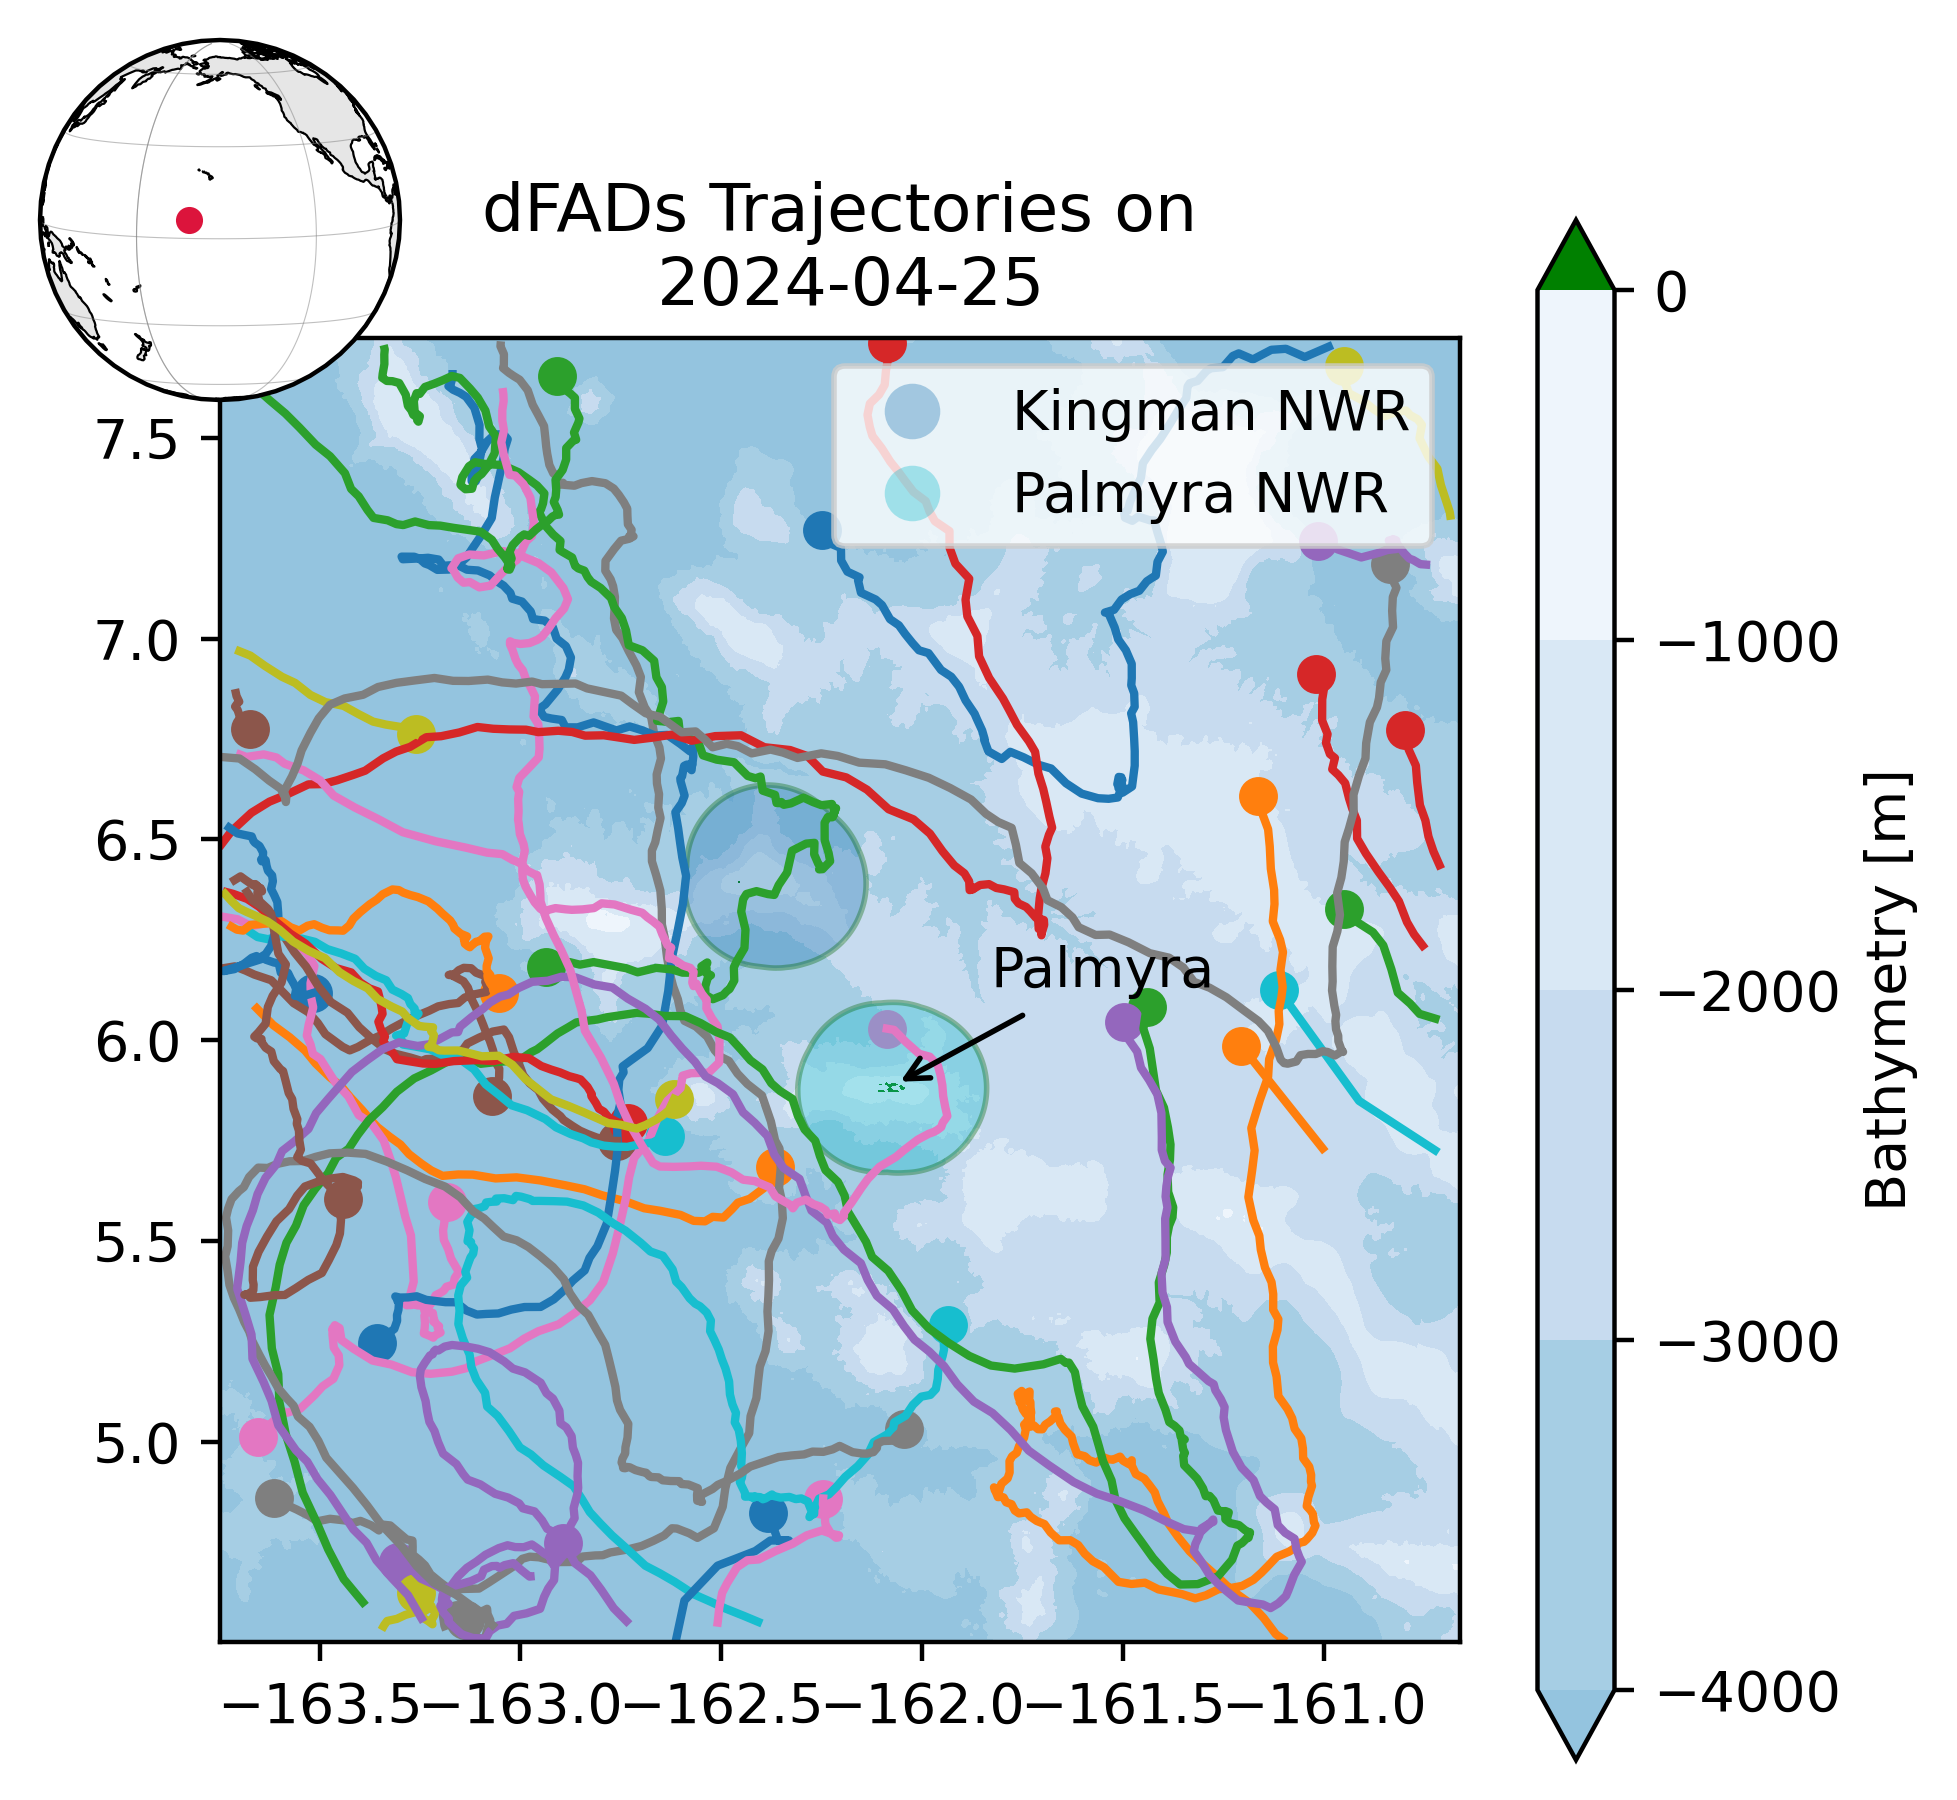

In [120]:
reload(plot)
## Plotting Data 
bouyids = activeday.index.unique()

fig, ax = plt.subplots(figsize = (5,5), dpi = 400)
fig, ax = plot.Add_bathymetry(fig, ax)

for id in bouyids: 
    traj = activeday.loc[id]
    if isinstance(traj, pd.Series):
        traj = traj.to_frame().T
    
    traj = traj.sort_values('TimeStamp')

    ax.plot(traj.lon, traj.lat)
    ax.scatter(traj.lon.iloc[-1], traj.lat.iloc[-1])

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

ax.set_title(f'dFADs Trajectories on\n {target_day.date()}')

# Center globe on the mean position of the latest point from each buoy
last_obs = activeday.sort_values("TimeStamp").groupby(level=0).tail(1)
center_lon = float(last_obs["lon"].mean())
center_lat = float(last_obs["lat"].mean())

# Place a small globe inset in the top-right corner of the existing axis
bbox = ax.get_position()  # in figure coordinates
w, h = 0.18, 0.18
x0 = bbox.x0 -w/2
y0 = bbox.y1 -h/2

globe_ax = fig.add_axes([x0, y0, w, h], projection=ccrs.Orthographic(center_lon+10, center_lat))
globe_ax.set_global()
globe_ax.add_feature(cfeature.LAND, facecolor="0.9")
globe_ax.add_feature(cfeature.OCEAN, facecolor="white")
globe_ax.coastlines(linewidth=0.4)
globe_ax.gridlines(linewidth=0.2, color="gray", alpha=0.5)

# Mark the region of interest on the globe
globe_ax.scatter(center_lon, center_lat, s=15, color="crimson", transform=ccrs.PlateCarree(), zorder=5)
lon, lat = plot.Palmyra_obj().xy
pal_lon, pal_lat =lon[0], lat[0]


ax.annotate( "Palmyra", xy=(pal_lon, pal_lat),xytext=(18, 18),textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1, color="black"),fontsize=10,zorder=8)
dataNWR = gpd.read_file(r"Data\Palmyra_Shapefiles",  layer = 'PAL_KING_NWR_12nm')
ax = plot.plot_NWPs(ax, dataNWR)
# ax.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
#           fancybox=True, shadow=True, ncol=3)
fig.savefig(r"..\Figures\paper\FIG1.pdf" , format = 'pdf')

In [121]:
def segment(activeday):
    # Sort so segmenting is done in time order within each trajectory
    activeday = activeday.sort_values(['BuoyID', 'TimeStamp']).copy()

    # Time gap threshold for starting a new segment
    gap = pd.Timedelta(days=2)

    # Time difference between consecutive points per BuoyID
    activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()

    # Segment id per BuoyID (0, 1, 2, ...)
    # increments whenever deltat >= gap
    activeday['segment_id'] = (
        activeday['deltat'].ge(gap)
        .groupby(activeday['BuoyID'])
        .cumsum()
        .astype(int)
    )

    # Optional: keep same indexing style as earlier cells
    activeday = activeday.set_index('BuoyID')
    return activeday


(596, 555, 4)


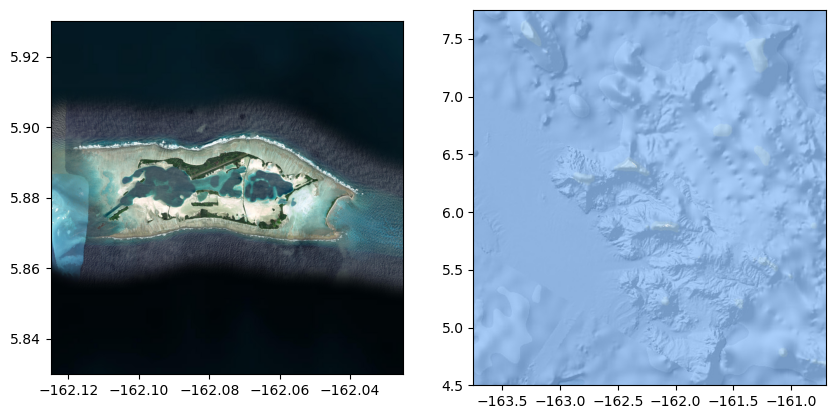

In [122]:
import contextily as ctx
from pyproj import Transformer


def load_sat_image(west, east, south, north, zoom = 8, 
                   provider = ctx.providers.Esri.WorldImagery):

    # Fetch tiles; ll=True means bounds are in lon/lat (WGS84)
    sat_img, ext_merc = ctx.bounds2img(west, south, east, north,
                                        zoom=zoom,
                                        source=provider,
                                        ll=True)
    # ext_merc is in Web Mercator — convert back to WGS84 for imshow
    t = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)
    left, bottom = t.transform(ext_merc[0], ext_merc[2])
    right, top   = t.transform(ext_merc[1], ext_merc[3])

    # Tiles snap to tile boundaries so the returned extent is slightly larger
    # than requested. Crop the image array to the exact requested bounds
    # so the inset never overflows its axes.
    h, w = sat_img.shape[:2]
    x0 = int(round((west  - left)   / (right - left)   * w))
    x1 = int(round((east  - left)   / (right - left)   * w))
    y0 = int(round((top   - north)  / (top   - bottom) * h))
    y1 = int(round((top   - south)  / (top   - bottom) * h))
    x0, x1 = max(0, x0), min(w, x1)
    y0, y1 = max(0, y0), min(h, y1)
    sat_img = sat_img[y0:y1, x0:x1]
    sat_ext = [west, east, south, north]

    return sat_img, sat_ext                                
# loading Palmyra photo
west_p, east_p = -162.125, -162.025
south_p, north_p = 5.83, 5.93
pal_img, pal_ext = load_sat_image(west_p, east_p, south_p, north_p, zoom =16, provider =ctx.providers.Esri.WorldImagery )
west, east = -163.75, -160.7
south, north = 4.5, 7.75
reg_img, reg_ext = load_sat_image(west, east, south, north, zoom =8, provider =ctx.providers.Esri.OceanBasemap )


fig, ax = plt.subplots(1,2, figsize = (10,10))
ax[0].imshow(pal_img, extent=pal_ext)
ax[1].imshow(reg_img, extent=reg_ext)
print(reg_img .shape)

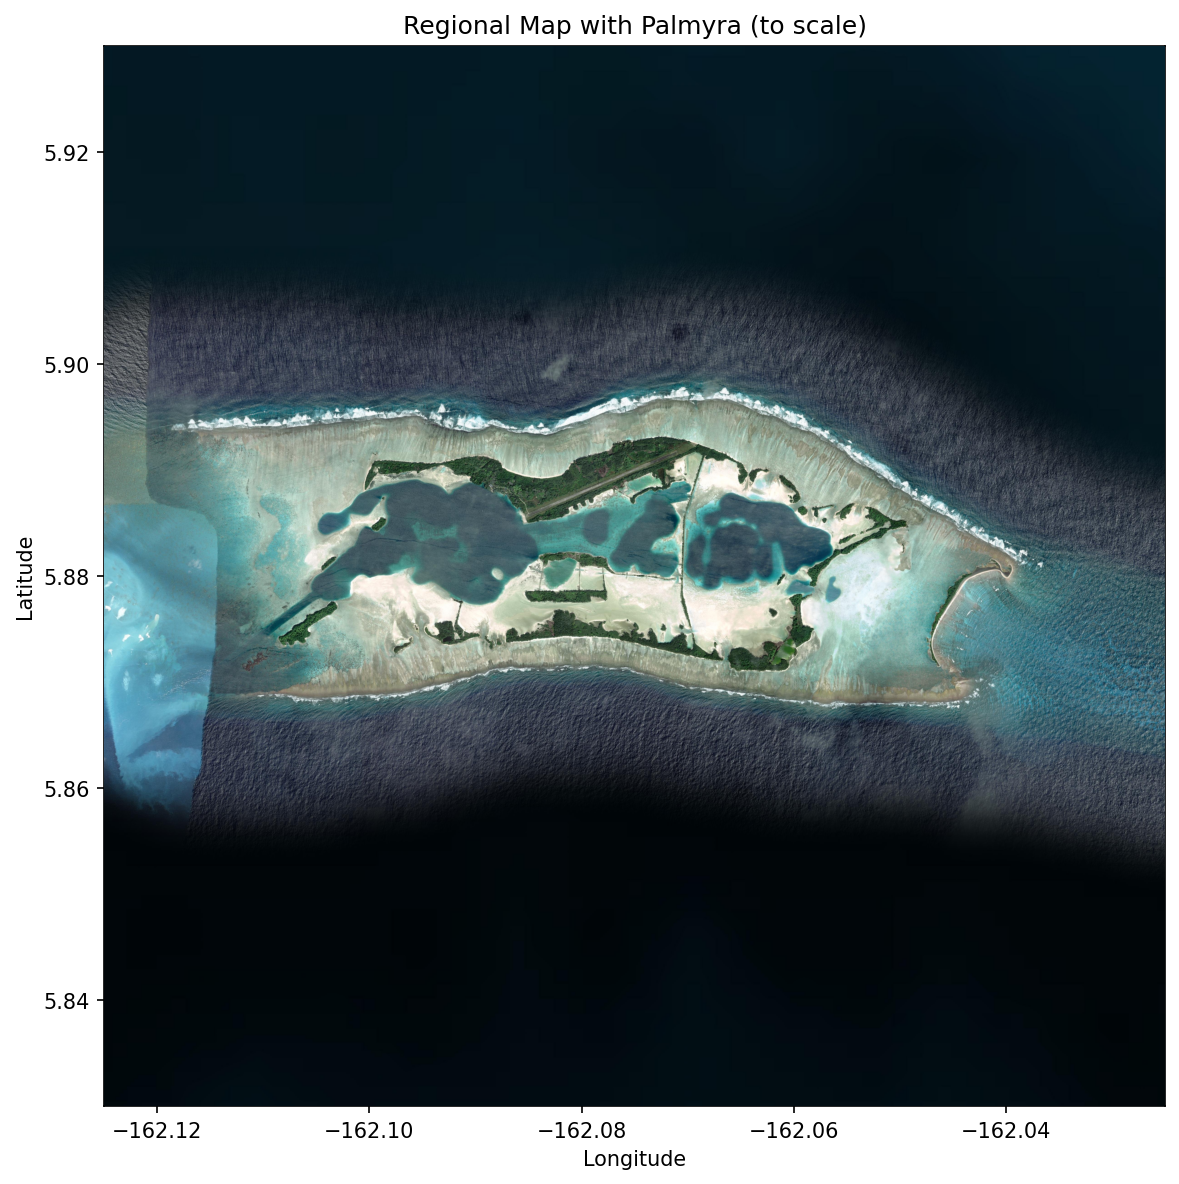

In [123]:
def inset_satImag(ax, reg_img, inset_img, reg_ext, inset_ext):
    ax.imshow(reg_img, extent=reg_ext, aspect='auto')
    pal_inset = ax.inset_axes(
        [inset_ext[0], inset_ext[2], inset_ext[1] - inset_ext[0], inset_ext[3] - inset_ext[2]],
        transform=ax.transData
    )
    pal_inset.imshow(inset_img, extent=inset_ext, aspect='auto')
    pal_inset.set_xticks([])
    pal_inset.set_yticks([])
    for spine in pal_inset.spines.values():
        spine.set_edgecolor('None')
    return ax , pal_inset


fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
ax, pal_inset = inset_satImag(ax, reg_img, pal_img, reg_ext, pal_ext)
ax.set_xlim(west_p, east_p)
ax.set_ylim(south_p, north_p)
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Regional Map with Palmyra (to scale)')
plt.tight_layout()
plt.show()



In [124]:
def segment(activeday):
    # Sort so segmenting is done in time order within each trajectory
    activeday = activeday.sort_values(['BuoyID', 'TimeStamp']).copy()

    # Time gap threshold for starting a new segment
    gap = pd.Timedelta(days=2)

    # Time difference between consecutive points per BuoyID
    activeday['deltat'] = activeday.groupby('BuoyID')['TimeStamp'].diff()

    # Segment id per BuoyID (0, 1, 2, ...)
    # increments whenever deltat >= gap
    activeday['segment_id'] = (
        activeday['deltat'].ge(gap)
        .groupby(activeday['BuoyID'])
        .cumsum()
        .astype(int)
    )

    # Optional: keep same indexing style as earlier cells
    activeday = activeday.set_index('BuoyID')
    return activeday

In [125]:
### Adding distance from palmyra 
import functions.output_functions as output
palmyra = funcs.Palmyra_obj()
x, y = palmyra.xy
longlist2 = funcs.generate_longlist(ds, extra_columns= ['mapped_u', 'mapped_v'])
longlist2['palmyra_lat'] = np.ones(len(longlist))*y
longlist2['palmyra_lon'] = np.ones(len(longlist))*x
longlist2['palmyra_distance'] = output.haversine_df(longlist2, 'lats', 'lons', 'palmyra_lat', 'palmyra_lon')
ds1 = pd.read_csv(r'Parcels/saved_output/Final/cmems_bias_pers_meanremoved_2026.csv')
ds1.Time = pd.to_datetime(ds1.Time)
merged = output.merge_forecast_true(ds1, longlist2)
import xarray as xr
merged = output.add_starttime(merged)
merged = output.calc_iniial_lat(merged)
merged = merged.rename(columns={'mapped_u': 'u_mapped', 'mapped_v': 'v_mapped'})
merged = output.calc_intial_speed_dif(merged)

q = xr.load_dataset('Data/regression_quantiles_leadtimes_cmems_bias_pers_2026.nc')

# 72-hour expected error
q72 = q.sel(q=0.90, leadtime=72, method='nearest')
merged['expected_error72'] = (q72.Intercept.values
                               + q72.initial_speed_dif_mag.values * merged.initial_speed_dif_mag
                               + q72.initial_lat.values * merged.initial_lat)

# 24-hour expected error
q24 = q.sel(q=0.90, leadtime=24, method='nearest')
merged['expected_error24'] = (q24.Intercept.values
                               + q24.initial_speed_dif_mag.values * merged.initial_speed_dif_mag
                               + q24.initial_lat.values * merged.initial_lat)

merged = output.calc_initial_lat_lon(merged)

# Dedup for 72h: one row per (BuoyID, start position) closest to leadtime 72
merged_dedup72 = (merged.assign(_d=(merged['leadtime'] - 72).abs())
                        .sort_values('_d')
                        .drop_duplicates(subset=['BuoyID', 'lati', 'loni'])
                        .drop(columns='_d')
                        [['BuoyID', 'lati', 'loni', 'expected_error72', 'lat_forcast', 'lon_forcast']]
                        .rename(columns={'lat_forcast': 'lat_forcast72', 'lon_forcast': 'lon_forcast72'}))

# Dedup for 24h: one row per (BuoyID, start position) closest to leadtime 24
merged_dedup24 = (merged.assign(_d=(merged['leadtime'] - 24).abs())
                        .sort_values('_d')
                        .drop_duplicates(subset=['BuoyID', 'lati', 'loni'])
                        .drop(columns='_d')
                        [['BuoyID', 'lati', 'loni', 'expected_error24', 'lat_forcast', 'lon_forcast']]
                        .rename(columns={'lat_forcast': 'lat_forcast24', 'lon_forcast': 'lon_forcast24'}))

# Merge 72h onto observations at the forecast start position
a = longlist2.merge(merged_dedup72,
                    how='left',
                    left_on=['BuoyID', 'lats', 'lons'],
                    right_on=['BuoyID', 'lati', 'loni']).drop(columns=['lati', 'loni'])

# Merge 24h onto same observations
a = a.merge(merged_dedup24,
            how='left',
            left_on=['BuoyID', 'lats', 'lons'],
            right_on=['BuoyID', 'lati', 'loni']).drop(columns=['lati', 'loni'])

assert len(a) == len(longlist2), f"Row count changed: {len(a)} vs {len(longlist2)}"

# Distance from 72h and 24h forecast positions to Palmyra
a['Forecast_distance_pal72'] = output.haversine_df(a, 'lat_forcast72', 'lon_forcast72', 'palmyra_lat', 'palmyra_lon')
a['Forecast_distance_pal24'] = output.haversine_df(a, 'lat_forcast24', 'lon_forcast24', 'palmyra_lat', 'palmyra_lon')

# Only compute threshold where a forecast exists (NaN > value = False, not NaN)
has72 = a['expected_error72'].notna()
has24 = a['expected_error24'].notna()
a['threshold72'] = np.where(has72, a['expected_error72'] > a['Forecast_distance_pal72'], np.nan)
a['threshold24'] = np.where(has24, a['expected_error24'] > a['Forecast_distance_pal24'], np.nan)

# Forward-fill each per BuoyID, then OR: red if either 24h or 72h fires
a = a.sort_values(['BuoyID', 'Time'])
a['threshold72'] = a.groupby('BuoyID')['threshold72'].ffill().fillna(False).astype(bool)
a['threshold24'] = a.groupby('BuoyID')['threshold24'].ffill().fillna(False).astype(bool)
a['threshold'] = a['threshold72'] | a['threshold24']


In [127]:
# load dFAD data, interpolate and calcauate segments
ds = gpd.read_parquet(r"Data\SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet")
print(ds.columns)
longlist = funcs.generate_longlist(ds)
longlist = a.rename(columns = {'Time' : 'TimeStamp', 'lats' : 'lat' , 'lons':'lon'})
longlist2 = segment(longlist)
interp = longlist2.groupby(['BuoyID', 'segment_id'], observed=False).apply(
    funcs.interpolate_dFADs, dt = pd.Timedelta(hours = 1), columns = ['lat', 'lon'],
     include_groups = False).reset_index(level= ['BuoyID','segment_id']).reset_index(drop = True)

interp = interp.sort_values(['BuoyID', 'segment_id', 'TimeStamp'])
interp['starttime'] = interp.groupby(['BuoyID', 'segment_id'])['TimeStamp'].transform('first')
interp = interp.sort_values('starttime').reset_index(drop = True)

colors = [plt.matplotlib.colors.to_hex(c) for c in plt.cm.tab20.colors]
group_colors = {
    key: np.random.choice(colors)
    for key in interp.groupby(['BuoyID', 'segment_id']).groups
}
interp['color'] = [
    group_colors[(buoy, segment)]
    for buoy, segment in zip(interp['BuoyID'], interp['segment_id'])
]



Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u', 'mapped_v_oscar', 'mapped_u_oscar', 'mapped_v_winds',
       'mapped_u_winds'],
      dtype='object')


In [128]:
thresh_obs = (longlist[['BuoyID', 'TimeStamp', 'threshold']]
              .sort_values('TimeStamp'))

interp = pd.merge_asof(
    interp.sort_values('TimeStamp'),
    thresh_obs,
    on='TimeStamp',
    by='BuoyID',
    direction='backward'
)

interp['threshold'] = interp['threshold'].fillna(False).astype(bool)
interp['color_scatter'] = interp['threshold'].map({True: 'red', False: 'black'})

In [129]:
def target_date(date, longlist):
    target_time = date
    past = longlist[longlist.TimeStamp < pd.to_datetime(target_time)].copy()
    past['last_time'] = past.groupby(['BuoyID', 'segment_id'], observed=False)['TimeStamp'].transform('last')
    past['last_time'] = pd.to_datetime(past['last_time'])
    past['last_time_diff'] = (past['last_time'] - target_time).abs()
    activeday = past[past['last_time_diff'] < pd.Timedelta(3*60, unit='minutes')].copy()
    activeday = activeday.set_index(['BuoyID'])
    return activeday

def draw_scalebars(ax, ref_lat=6.0):
    """Draw scale bars and return the resulting line/text artists."""
    cos_lat = np.cos(np.radians(ref_lat))
    km_per_deg_lon = 111.32 * cos_lat
    bars = [
        (16.0934 * 2.5 / km_per_deg_lon, "25 mi"),
        (10.0 * 5      / km_per_deg_lon, "50 km"),
    ]
    x_end, y_start, dy = 0.9, 0.95, 0.06
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x_span, y_span = xlim[1] - xlim[0], ylim[1] - ylim[0]
    artists = []
    for i, (width_deg, label) in enumerate(bars):
        y_frac       = y_start - i * dy
        x_end_data   = xlim[0] + x_end * x_span
        x_start_data = x_end_data - width_deg
        y_data       = ylim[0] + y_frac * y_span
        line, = ax.plot([x_start_data, x_end_data], [y_data, y_data],
                        color='black', lw=2, solid_capstyle='butt', zorder=10)
        txt = ax.text(x_end_data, y_data, f'  {label}',
                      va='center', ha='left', fontsize=7, zorder=10)
        artists.extend([line, txt])
    return artists

In [130]:
import matplotlib as mpl

# Increase the limit to 50 MB
mpl.rcParams['animation.embed_limit'] = 50.0 

loaded sat images
Artist pool size: 54
Saving animation to MP4...
Done!


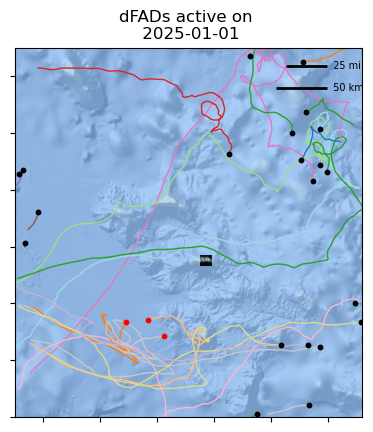

In [131]:
%matplotlib inline
import matplotlib.animation as animation
from IPython.display import HTML

## date range to plot 
dates = pd.date_range('2024-08-01', '2025-01-01', freq=pd.Timedelta(3, 'hour'))

west_p, east_p = -162.125, -162.025
south_p, north_p = 5.83, 5.93
pal_img, pal_ext = load_sat_image(west_p, east_p, south_p, north_p, zoom=15, provider=ctx.providers.Esri.WorldImagery)
west, east = -163.75, -160.7
south, north = 4.5, 7.75
reg_img, reg_ext = load_sat_image(west, east, south, north, zoom=8, provider=ctx.providers.Esri.OceanBasemap)
print('loaded sat images')
interp.TimeStamp = interp.TimeStamp.dt.round('h')
interp_toplot = interp[(interp.TimeStamp >= dates[0]) & (interp.TimeStamp <= dates[-1])].copy().sort_values(['starttime', 'TimeStamp'])

# Size the artist pool to the max number of concurrently active buoys
# (avoids looping over all 10^3 IDs per frame — only n_pool iterations needed)
max_active = int(interp_toplot.groupby('TimeStamp')['BuoyID'].nunique().max())
print(f"Artist pool size: {max_active}")

fig, ax = plt.subplots()
ax, ax_inset= inset_satImag(ax , reg_img, pal_img, reg_ext, pal_ext)
#ax.imshow(reg_img, extent=reg_ext, aspect='auto', zorder=0)
ax.set_xlim(-163.75, -160.7)
ax.set_ylim(4.5, 7.75)
# ax.set_xlim(west_p,east_p)
# ax.set_ylim(south_p, north_p)
ax.tick_params(labelbottom=False, labelleft=False)
ax.set_aspect('equal')
draw_scalebars(ax)

# Fixed pool of artists — reused each frame regardless of which buoy occupies the slot
pool_lines = [ax.plot([], [], lw=1)[0]                     for _ in range(max_active)]
pool_dots  = [ax.scatter([], [], color='k', s=10, zorder=5) for _ in range(max_active)]
title = ax.set_title('')
all_artists = pool_lines + pool_dots + [title]

def update(date):
    activeday = target_date(date, interp_toplot)
    # active_list is short (10-100), not the full buoy universe
    active_list = list(activeday.index.unique())

    for i in range(max_active):
        if i < len(active_list):
            bid = active_list[i]
            traj = activeday.loc[bid]
            if isinstance(traj, pd.Series):
                traj = traj.to_frame().T
            traj = traj.sort_values('TimeStamp')

            pool_lines[i].set_data(traj.lon.values, traj.lat.values)
            pool_lines[i].set_color(traj.color.iloc[0])
            pool_lines[i].set_visible(True)

            pool_dots[i].set_offsets([[traj.lon.iloc[-1], traj.lat.iloc[-1]]])
            pool_dots[i].set_visible(True)
            pool_dots[i].set_color(traj.color_scatter.iloc[-1])
        else:
            pool_lines[i].set_data([], [])
            pool_lines[i].set_visible(False)
            pool_dots[i].set_offsets(np.empty((0, 2)))
            pool_dots[i].set_visible(False)

    title.set_text(f'dFADs active on \n {date.date()}')
    return all_artists

ani = animation.FuncAnimation(fig, update, frames=dates, interval=100, blit=True)

# plt.close(fig)
# HTML(ani.to_jshtml())

print("Saving animation to MP4...")
ani.save(r"..\Figures\Animations\Active_dFADs_2024_jan_sat_colored2.mp4", writer='ffmpeg', dpi=100)
print("Done!")

In [48]:
%matplotlib inline
import matplotlib.animation as animation

## ── Parameters ────────────────────────────────────────────────────────────────
zoom_days   = 20         # days over which the camera zooms from Palmyra → region
dates_zoom  = pd.date_range('2024-04-01', '2025-01-10', freq=pd.Timedelta(2, 'hour'))
n_frames    = len(dates_zoom)
print(f'number of frames {n_frames}')
zoom_frames = int(zoom_days * 24 / 3)   # number of 3-hour steps in the zoom period

# Palmyra bounds and load lat data
west_p, east_p = -162.125, -162.025
south_p, north_p = 5.83, 5.93
pal_img, pal_ext = load_sat_image(west_p, east_p, south_p, north_p, zoom=15, provider=ctx.providers.Esri.WorldImagery)
west, east = -163.75, -160.7
south, north = 4.5, 7.75
reg_img, reg_ext = load_sat_image(west, east, south, north, zoom=9, provider=ctx.providers.Esri.OceanBasemap)
print('loaded sat data')
# Smooth cosine ease-in-out from Palmyra → region over zoom_frames
t_zoom = np.minimum(np.arange(n_frames) / zoom_frames, 1.0)
ease   = (1 - np.cos(t_zoom * np.pi)) / 2

xlim_w = west_p  + ease * (west  - west_p)
xlim_e = east_p  + ease * (east  - east_p)
ylim_s = south_p + ease * (south - south_p)
ylim_n = north_p + ease * (north - north_p)

# ── Subset data ───────────────────────────────────────────────────────────────
interp.TimeStamp = interp.TimeStamp.dt.round('h')
interp_ani = interp[
    (interp.TimeStamp >= dates_zoom[0]) & (interp.TimeStamp <= dates_zoom[-1])
].copy().sort_values(['starttime', 'TimeStamp'])

max_active_ani = int(interp_ani.groupby('TimeStamp')['BuoyID'].nunique().max())
print(f"Artist pool size: {max_active_ani}")

# ── Build figure ──────────────────────────────────────────────────────────────
fig_ani, ax_ani = plt.subplots(figsize = (8,8), dpi=400)
ax_ani, pal_inset = inset_satImag(ax_ani, reg_img, pal_img, reg_ext, pal_ext)
pal_inset.set_xlim(west_p, east_p)
pal_inset.set_ylim(south_p, north_p)
ax_ani.set_xlim(west_p, east_p)
ax_ani.set_ylim(south_p, north_p)
#ax_ani.tick_params(labelbottom=False, labelleft=False)

pool_lines_ani = [ax_ani.plot([], [], lw=2)[0]                      for _ in range(max_active_ani)]
pool_dots_ani  = [ax_ani.scatter([], [], color='k', s=25, zorder=5) for _ in range(max_active_ani)]
title_ani  = ax_ani.set_title('')
scalebar_c = []   # mutable container — rebuilt each frame after limits change

def update_zoom(i):
    date = dates_zoom[i]

    ax_ani.set_xlim(xlim_w[i], xlim_e[i])
    ax_ani.set_ylim(ylim_s[i], ylim_n[i])

    # for a in scalebar_c:
    #     a.remove()
    # scalebar_c.clear()
    # scalebar_c.extend(draw_scalebars(ax_ani))

    activeday  = target_date(date, interp_ani)
    active_list = list(activeday.index.unique())

    for j in range(max_active_ani):
        if j < len(active_list):
            bid  = active_list[j]
            traj = activeday.loc[bid]
            if isinstance(traj, pd.Series):
                traj = traj.to_frame().T
            traj = traj.sort_values('TimeStamp')
            pool_lines_ani[j].set_data(traj.lon.values, traj.lat.values)
            pool_lines_ani[j].set_color(traj.color.iloc[0])
            pool_lines_ani[j].set_visible(True)
            pool_dots_ani[j].set_offsets([[traj.lon.iloc[-1], traj.lat.iloc[-1]]])
            pool_dots_ani[j].set_visible(True)
        else:
            pool_lines_ani[j].set_data([], [])
            pool_lines_ani[j].set_visible(False)
            pool_dots_ani[j].set_offsets(np.empty((0, 2)))
            pool_dots_ani[j].set_visible(False)

    title_ani.set_text(f'{date.date()} \n Active dFADs: {len(active_list)}')

ani_zoom = animation.FuncAnimation(fig_ani, update_zoom, frames=range(n_frames), interval=100, blit=False)


print("Saving zoom animation to MP4...")
ani_zoom.save(r"..\Figures\Animations\Active_dFADs_zoom.mp4", writer='ffmpeg', dpi=400)
print("Done")
plt.close(fig_ani)

number of frames 3409
loaded sat data
Artist pool size: 54
Saving zoom animation to MP4...
Done
